In [1]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
###########'AUM GROWTH OF SBI COMPARISON TO OTHER FUND HOUSES'##############

In [3]:
data_aum_by_fund=pd.read_csv('../data/processed/cleaned_03_aum_by_fund_house.csv')

In [14]:
data_aum_by_fund.info()
data_aum_by_fund['date']=pd.to_datetime(data_aum_by_fund['date']).dt.year

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [37]:
data_for_analysis = data_aum_by_fund.groupby(['date','fund_house'])['aum_crore'].sum().reset_index()
data_for_analysis.head()

,date,fund_house,aum_crore
0,2022,Aditya Birla Sun Life MF,563000
1,2022,Axis Mutual Fund,490000
2,2022,DSP Mutual Fund,222000
3,2022,HDFC Mutual Fund,880000
4,2022,ICICI Prudential MF,953000


Text(0.5, 1.0, 'AUM GROWTH OF SBI COMPARED TO OTHER FUND HOUSES')

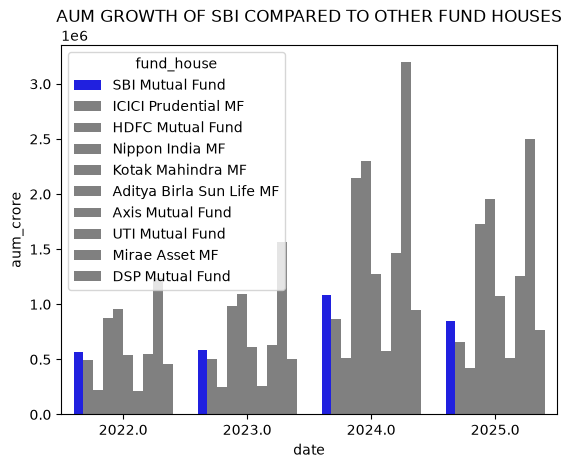

In [36]:
sns.barplot(x='date',y='aum_crore',data=data_for_analysis,estimator=sum,hue=data_aum_by_fund['fund_house'],palette={"SBI Mutual Fund": "blue", "HDFC Mutual Fund": "grey", "ICICI Prudential Mutual Fund": "grey", "Aditya Birla Sun Life Mutual Fund": "grey", "Axis Mutual Fund": "grey",
                                                                                                                    'Mirae Asset MF':"grey", 'Nippon India MF':"grey", 'DSP Mutual Fund':"grey", 'Aditya Birla Sun Life MF':"grey", 'UTI Mutual Fund':"grey", 'ICICI Prudential MF':"grey", 'Kotak Mahindra MF':"grey"})
plt.title('AUM GROWTH OF SBI COMPARED TO OTHER FUND HOUSES')

In [39]:
############# Monthly SIP Trend ######################

In [40]:
data_sip_trend=pd.read_csv('../data/processed/cleaned_04_monthly_sip_inflows.csv')
data_sip_trend.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [ ]:
px.bar(data_sip_trend, x='month', y='sip_inflow_crore', title='Monthly SIP Inflows Trend by Fund House')

In [49]:
############# Catefory Inflow Heatmap ######################

In [ ]:
data_category=pd.read_csv('../data/processed/cleaned_05_category_inflows.csv')
data_category['month'] = pd.to_datetime(data_category['month']).dt.month
data_category.head()
heatmap_data = data_category.pivot_table(
    index='category',   
    columns='month',   
    values='net_inflow_crore',  
    aggfunc='sum'      
)

<Axes: xlabel='month', ylabel='category'>

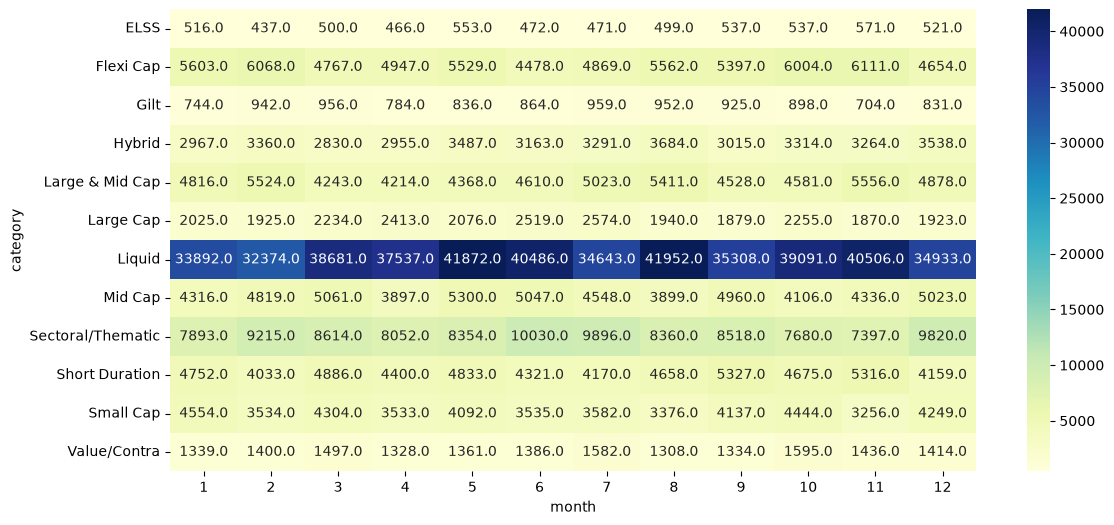

In [65]:
plt.figure(figsize=(13, 6))
sns.heatmap(data=heatmap_data,annot=True,fmt='.1f',cmap='YlGnBu')

In [66]:
################ Investor Demographics ######################

In [68]:
data_investor=pd.read_csv('../data/processed/cleaned_08_investor_transactions.csv')
data_investor.head()

,investor_id,date,amfi_code,transaction_type,amount,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


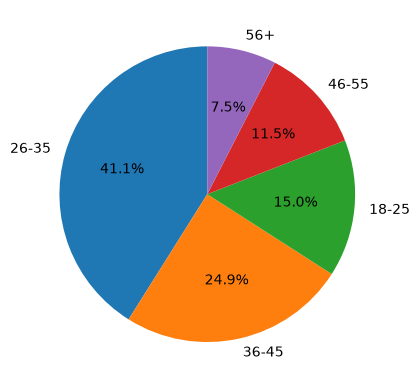

In [75]:
plt.pie(data_investor['age_group'].value_counts(), labels=data_investor['age_group'].value_counts().index, autopct='%1.1f%%', startangle=90)

In [85]:
data_investor_gp=data_investor[data_investor['transaction_type']=='SIP'].groupby('age_group')['amount'].sum().reset_index()
data_investor_gp.head()

,age_group,amount
0,18-25,32300613
1,26-35,88587340
2,36-45,53623247
3,46-55,25614556
4,56+,17107735


<Axes: xlabel='age_group', ylabel='amount'>

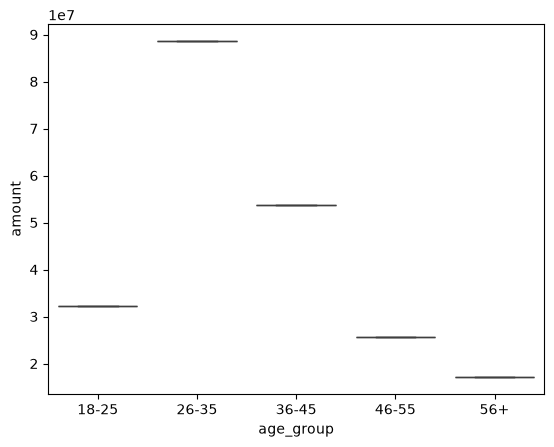

In [87]:
sns.boxplot(
    data=data_investor_gp, 
    x='age_group', 
    y='amount')

In [88]:
######### Geopraphic Distribution ##################

In [89]:
data_investor_geo=data_investor.groupby('state')['amount'].sum().reset_index()
data_investor_geo.head()

,state,amount
0,Delhi,289633404
1,Gujarat,298358940
2,Haryana,279634354
3,Karnataka,273753570
4,Madhya Pradesh,308312493


In [91]:
px.bar(data_investor_geo, x='amount', y='state', title='Geographic Distribution of Investors by State')

In [92]:
data_tier=data_investor.groupby('city_tier')['amount'].sum().reset_index()
data_tier.head()

,city_tier,amount
0,B30,1202325640
1,T30,2319254790


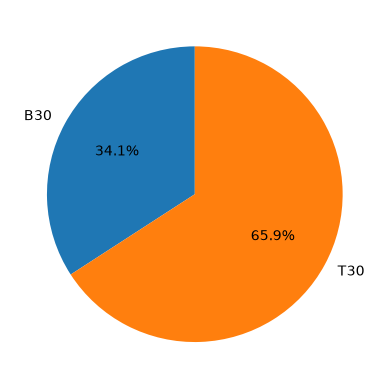

In [93]:
plt.pie(data_tier['amount'], labels=data_tier['city_tier'], autopct='%1.1f%%', startangle=90)

In [2]:
############### Folio count Growth ######################

<Axes: xlabel='month', ylabel='total_folios_crore'>

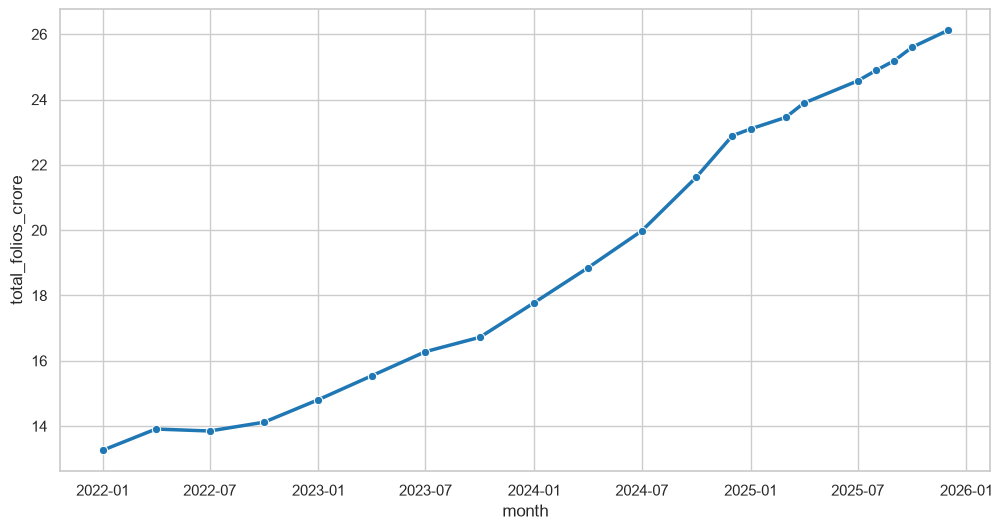

In [ ]:

df_folios = pd.read_csv('../data/processed/cleaned_06_industry_folio_count.csv')
df_folios['month'] = pd.to_datetime(df_folios['month'])
df_folios = df_folios.sort_values('month')
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df_folios, x='month', y='total_folios_crore', 
             linewidth=2.5, color='#1f77b4', marker='o')

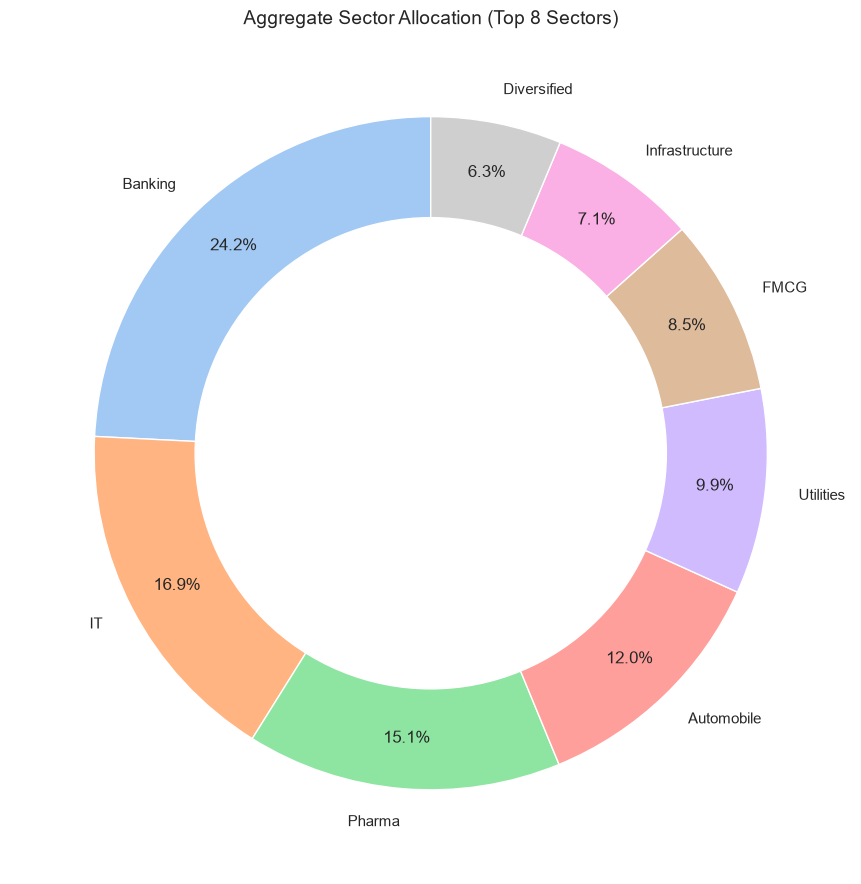

In [23]:

df_holdings = pd.read_csv('../data/processed/cleaned_09_portfolio_holdings.csv')

sector_alloc = df_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(9, 9))
colors = sns.color_palette('pastel')[0:8]

plt.pie(sector_alloc, labels=sector_alloc.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, pctdistance=0.85)

center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

plt.title('Aggregate Sector Allocation (Top 8 Sectors)', fontsize=14)
plt.tight_layout()
plt.show()